In [64]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    matthews_corrcoef, roc_auc_score
)
import seaborn as sns

In [37]:
K = 20

x = np.load("../data/Processed/WESAD_X.npy")
y = np.load("../data/Processed/WESAD_Y.npy")
print(x.shape)
print(y.shape)

subject_ind = [0, 3010, 6183, 9365, 12376, 15882, 18472, 21176, 23758, 26477, 29064, 31803, 34548, 37075, 39861, 42792]

X_train = x[:subject_ind[-2]]
X_test = x[subject_ind[-2]:]
Y_train = y[:subject_ind[-2]]
Y_test = y[subject_ind[-2]:]
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

dot = np.dot(X_train_scaled, X_test_scaled.T)
norm_factor = np.expand_dims(np.linalg.norm(X_train_scaled, axis=1), 1) @ np.expand_dims(np.linalg.norm(X_test_scaled, axis=1), 0)

similarity = dot/norm_factor
top_k_similar = np.argsort(similarity, axis=0)[-K:, :]


print(top_k_similar)




(42792, 189)
(42792,)
[[ 4756 27227  4757 ...  3923 27927 26490]
 [27398 27398 27240 ... 26481 27928 28198]
 [ 4762  4762  6156 ... 26482 28198 27927]
 ...
 [27236 27235 27235 ...  4456 26484 26487]
 [27232 27232 27236 ... 26487 26486 26484]
 [27235 27236 27237 ... 26486 26487 26486]]


In [39]:
print(similarity[4756  ,0])
print(similarity[27235   ,0])

0.9072666503142235
0.9411631588497982


Precision: [0.85230655 0.22510823 0.        ]   Recall:[0.96179681 0.14364641 0.        ]    F1:0.7993858751279427


<Axes: >

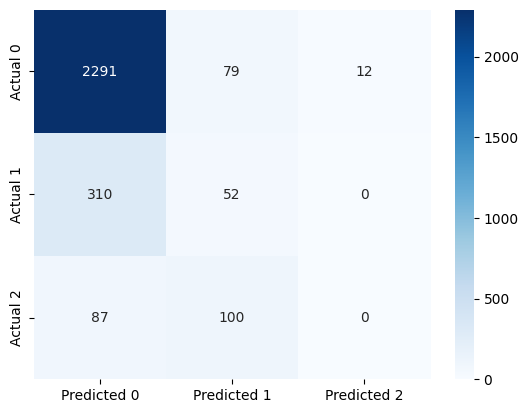

In [69]:
def per_class_precision_recall_from_cm(cm):
    cm = np.asarray(cm)
    tp = np.diag(cm)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp

    precision = np.divide(tp, tp + fp, out=np.zeros_like(tp, dtype=float), where=(tp + fp) != 0)
    recall    = np.divide(tp, tp + fn, out=np.zeros_like(tp, dtype=float), where=(tp + fn) != 0)
    return precision, recall

num_test, _ = X_test.shape
unique, counts = np.unique(Y_train.copy(), return_counts=True)

y_test = []
y_pred = []

for test_id in range(num_test):
    label = Y_test[test_id]
    sample = Y_train[top_k_similar[:, test_id]]

    pred = np.bincount(sample, minlength=3).argmax()

    y_test.append(label)
    y_pred.append(pred)

cm = confusion_matrix(np.array(y_test), np.array(y_pred), labels=unique)
f1 = f1_score(np.array(y_test), np.array(y_pred), average='micro', labels=unique)

precision, recall = per_class_precision_recall_from_cm(cm)

print(f"Precision: {precision}   Recall:{recall}    F1:{f1}")
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=[f"Predicted {i}" for i in range(len(unique))],
    yticklabels=[f"Actual {i}" for i in range(len(unique))]
)